# Limpieza y transformacion de los datos
Fecha: 29 de mayo del 2026

Autor : Angel de jesus mtz rdz

In [ ]:
#Importamos librerias

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Importamks librerias para graficas
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
#Cargamos el dataset crudo/sucio
dfCrudo = pd.read_csv("../Data/dataset_sucio_practica.csv")

In [6]:
dfCrudo

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
...,...,...,...,...,...,...,...,...
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No


In [7]:
#Generar una copia del datframe
dfCrudoCopia = dfCrudo.copy()

In [8]:
dfCrudoCopia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    object 
 2   edad            110 non-null    float64
 3   correo          125 non-null    object 
 4   pais            82 non-null     object 
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    object 
 7   activo          90 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.9+ KB


In [9]:
dfCrudoCopia.describe()

,id,edad,salario
count,125.000000,110.000000,107.000000
mean,58.200000,43.945455,14093.457944
std,35.906465,47.489803,8825.918852
min,1.000000,-5.000000,-1000.000000
25%,27.000000,22.750000,12000.000000
50%,58.000000,30.000000,15000.000000
75%,89.000000,40.000000,18000.000000
max,120.000000,150.000000,25000.000000


In [10]:
#Mostramos el valor total de valores nulos
dfCrudoCopia.isnull().sum()

id                 0
nombre             9
edad              15
correo             0
pais              43
salario           18
fecha_registro     0
activo            35
dtype: int64

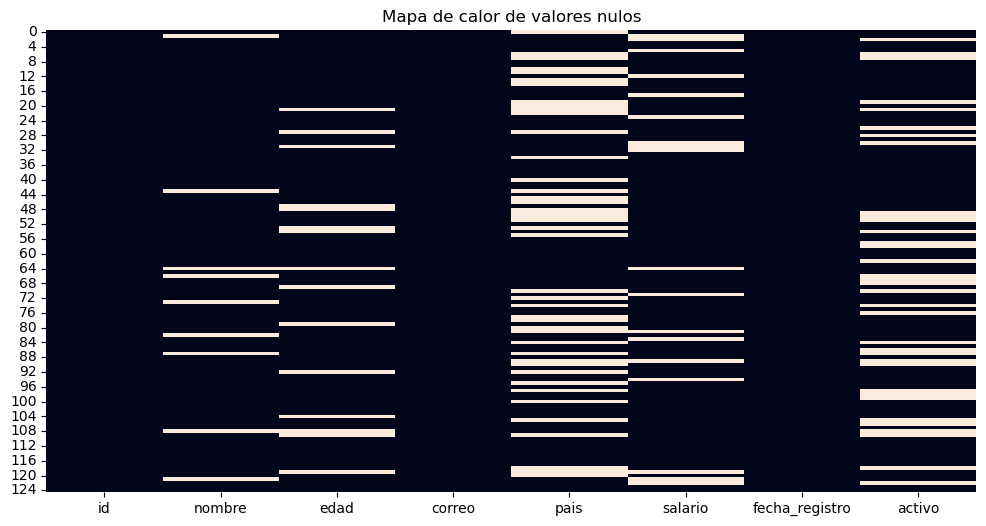

In [12]:
plt.figure (figsize=(12,6))
sns.heatmap(dfCrudoCopia.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos")
plt.show()

# LIMPIEZA DE DATOS
1. Eliminar datos duplicados
2. Imputar valores nulos
3. Corregir outlier (Valores fuera de rango)

In [13]:
# 1. Eliminamos datos duplicados
dfCrudoCopia.duplicated().sum()

np.int64(5)

In [14]:
dfCrudoCopia.drop_duplicates(inplace=True) #Elimina datos duplicados

In [15]:
dfCrudoCopia.duplicated().sum()

np.int64(0)

In [18]:
# 2. Verificamos la existencia de edades fuera de rango
dfCrudoCopia[(dfCrudoCopia["edad"]<0 )| (dfCrudoCopia["edad"]>100)
]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
6,7,Roberto Smith,-5.0,vegasara@yahoo.com,NaN,12000.0,2026-03-31,NaN
7,8,Nicholas Torres,-5.0,arnoldjoe@macias.biz,NaN,12000.0,2026-04-07,NaN
9,10,Angela Richards,-5.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
12,13,Paul Liu,150.0,ilong@gmail.com,España,NaN,2025-11-21,No
16,17,Christopher Klein,-5.0,ericarice@hotmail.com,España,18000.0,2024-09-22,Sí
22,23,Mrs. Diane Carter,150.0,schultzpatrick@mccoy.net,NaN,18000.0,2024-10-31,No
23,24,Vicki Love,-5.0,antonio14@johnson.net,Argentina,NaN,2026-01-24,No
24,25,Matthew Porter,-5.0,hansoncameron@yahoo.com,Argentina,12000.0,2025-11-17,No


In [22]:
#Convertimos las edades invalidadas en NaN
dfCrudoCopia.loc[
    (dfCrudoCopia["edad"]<0) | (dfCrudoCopia["edad"]>100),"edad"
    ] = np.nan

In [23]:
dfCrudoCopia[(dfCrudoCopia["edad"]<0 )| (dfCrudoCopia["edad"]>100)
]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [25]:
#Calculamos la mediana del campo edad
mediana_edad = dfCrudoCopia["edad"].median()
mediana_edad

30.0

In [26]:
dfCrudoCopia["edad"]= dfCrudoCopia["edad"].fillna(mediana_edad)

In [27]:
dfCrudoCopia["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [30]:
# Identificar los salarios negativos
dfCrudoCopia.loc[
(dfCrudoCopia["salario"]<0)
] = np.nan

In [31]:
dfCrudoCopia[(dfCrudoCopia["salario"]<0 )]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [32]:
mediana_salario = dfCrudoCopia["salario"].median()
mediana_salario

15000.0

In [33]:
dfCrudoCopia["salario"]= dfCrudoCopia["salario"].fillna(mediana_salario)

In [34]:
dfCrudoCopia["salario"].describe()

count      120.000000
mean     16741.666667
std       4401.099621
min      12000.000000
25%      15000.000000
50%      15000.000000
75%      18000.000000
max      25000.000000
Name: salario, dtype: float64

In [35]:
dfCrudoCopia.describe()

,id,edad,salario
count,99.000000,99.000000,120.000000
mean,62.121212,30.121212,16741.666667
std,35.313833,4.740776,4401.099621
min,1.000000,22.000000,12000.000000
25%,32.500000,30.000000,15000.000000
50%,65.000000,30.000000,15000.000000
75%,92.500000,30.000000,18000.000000
max,120.000000,40.000000,25000.000000


In [36]:
#Variables de tipo cadena / string / object
dfCrudoCopia[
    ~dfCrudoCopia["correo"].str.contains("@", na=False)
]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4.0,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5.0,Elaine Sanchez,30.0,correo_invalido,México,25000.0,2025-03-28,Sí
9,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,NaN
11,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,NaN
18,19.0,Nicholas Curry,35.0,correo_invalido,México,12000.0,2025-11-22,Sí
20,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,NaN
21,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,NaN
26,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,NaN
27,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,NaN
28,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,NaN


In [38]:
correos_invalidos = ~dfCrudoCopia["correo"].str.contains("@", na=False)
correos_invalidos                                                        

0      False
1      False
2      False
3       True
4       True
       ...  
115    False
116    False
117    False
118     True
119    False
Name: correo, Length: 120, dtype: bool

In [39]:
dfCrudoCopia.loc[correos_invalidos, "correo"] = pd.NA

In [42]:
dfCrudoCopia["correo_valido"] = dfCrudoCopia["correo"].str.contains("@",na=False)

In [44]:
#mostramos lo primeros 5 resultados
dfCrudoCopia.head(5)

,id,nombre,edad,correo,pais,salario,fecha_registro,activo,correo_valido
0,1.0,Julia Zhang,30.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí,True
1,2.0,NaN,35.0,asimmons@garza.com,España,15000.0,2026-05-04,No,True
2,3.0,George Burke,40.0,mcclainerin@gmail.com,Argentina,15000.0,2026-01-27,NaN,True
3,NaN,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>,False
4,NaN,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>,False


In [40]:
dfCrudoCopia

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1.0,Julia Zhang,30.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2.0,NaN,35.0,asimmons@garza.com,España,15000.0,2026-05-04,No
2,3.0,George Burke,40.0,mcclainerin@gmail.com,Argentina,15000.0,2026-01-27,NaN
3,NaN,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>
4,NaN,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>
...,...,...,...,...,...,...,...,...
115,116.0,Samuel Roth,30.0,robertsmith@taylor.info,España,12000.0,2024-12-10,Sí
116,117.0,Kristina Buchanan,30.0,rmurphy@gmail.com,Argentina,18000.0,2024-11-18,No
117,118.0,Michael Harper,30.0,ndaniels@gmail.com,Argentina,12000.0,2026-04-29,No
118,NaN,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>


In [45]:
dfCrudoCopia["pais"].isnull().sum()

np.int64(60)

In [50]:
pais_moda = dfCrudoCopia["pais"].mode()[0]

In [53]:
#Asiganamos el pais mas repetitivo a nulos
dfCrudoCopia["pais"] = dfCrudoCopia["pais"].fillna(pais_moda)

In [54]:
#mostramos el total de valores nulos
dfCrudoCopia["pais"].isnull().sum()

np.int64(0)

In [55]:
dfCrudoCopia.dtypes

id                float64
nombre             object
edad              float64
correo             object
pais               object
salario           float64
fecha_registro     object
activo             object
correo_valido        bool
dtype: object

In [56]:
#convertimos la fecha registro a DateTime
dfCrudoCopia["fecha_registro"] = pd.to_datetime(dfCrudoCopia["fecha_registro"])

In [57]:
dfCrudoCopia["fecha_registro"].dtype

dtype('<M8[ns]')

In [58]:
dfCrudoCopia.dtypes

id                       float64
nombre                    object
edad                     float64
correo                    object
pais                      object
salario                  float64
fecha_registro    datetime64[ns]
activo                    object
correo_valido               bool
dtype: object

In [59]:
#campo activo
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
Sí      36
<NA>    30
No      28
NaN     26
Name: count, dtype: int64

In [60]:
dfCrudoCopia["activo"] = dfCrudoCopia["activo"].fillna("Sí")

In [61]:
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
Sí    92
No    28
Name: count, dtype: int64

In [63]:
#categorizamos el campo activo
dfCrudoCopia["activo"] = dfCrudoCopia["activo"].map(
{
    "Sí": 1,
    "No": 0
})

In [64]:
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
1    92
0    28
Name: count, dtype: int64

In [ ]:
# conclusiones
durante la practica se identificaron y corrigieron las siguientes anomalias:
1. Valores duplicados
2. Valores nulos
3. Los tipos de datos estaban en negatativo
4. Algunos valores estaban en NaN 
5. Se eliminaron datos duplicados en registros
6. El timestand se corrigio